# Model Calibration

This notebook evaluates whether the selected Gradient Boosting model's scores align with observed failure frequencies. It separates three ideas:

- **Classification** applies a decision threshold to assign a class.
- **Discrimination** measures whether failures rank above non-failures.
- **Calibration** measures whether a score such as 0.70 corresponds to an observed frequency near 70%.

A model can discriminate well while still producing poorly calibrated probabilities. No classifier tuning or production export is performed here.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (average_precision_score, brier_score_loss, f1_score,
                             log_loss, precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", context="notebook")

## 1. Load and prepare the data

The feature engineering, stratified split, and leakage exclusions exactly match notebooks 02 and 03. Failure-mode labels and identifiers are validation columns only; they never enter the predictive matrix.

In [2]:
df = pd.read_csv("../data/raw/ai4i2020.csv")
target_column = "Machine failure"
identifier_columns = ["UDI", "Product ID"]
failure_mode_columns = ["TWF", "HDF", "PWF", "OSF", "RNF"]
base_features = ["Type", "Air temperature [K]", "Process temperature [K]",
                 "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]

X = df[base_features].copy()
y = df[target_column].copy()
X["Temperature difference"] = X["Process temperature [K]"] - X["Air temperature [K]"]
X["Power proxy"] = X["Rotational speed [rpm]"] * X["Torque [Nm]"]
X["Mechanical strain proxy"] = X["Torque [Nm]"] * X["Tool wear [min]"]

for forbidden in identifier_columns + failure_mode_columns + [target_column]:
    assert forbidden not in X.columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
split_summary = pd.DataFrame({
    "Observations": [len(y_train), len(y_test)],
    "Failures": [int(y_train.sum()), int(y_test.sum())],
    "Failure rate": [y_train.mean(), y_test.mean()],
}, index=["Training", "Holdout"])
display(split_summary.style.format({"Failure rate": "{:.2%}"}))

,Observations,Failures,Failure rate
Training,8000,271,3.39%
Holdout,2000,68,3.40%


## 2. Recreate the selected model pipeline

Encoding and scaling remain inside the pipeline. During calibration cross-validation, each cloned pipeline learns preprocessing only from its fold's training observations. The classifier architecture is unchanged and no hyperparameters are tuned.

In [3]:
categorical_features = ["Type"]
numerical_features = [column for column in X.columns if column != "Type"]

def make_gradient_boosting_pipeline():
    preprocessor = ColumnTransformer([
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", StandardScaler(), numerical_features),
    ])
    return Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(random_state=42)),
    ])

def probability_metrics(y_true, model_scores):
    labels_at_050 = (model_scores >= 0.50).astype(int)
    return {
        "Brier Score": brier_score_loss(y_true, model_scores),
        "Log Loss": log_loss(y_true, model_scores),
        "ROC-AUC": roc_auc_score(y_true, model_scores),
        "Average Precision": average_precision_score(y_true, model_scores),
        "Precision @ 0.50": precision_score(y_true, labels_at_050, zero_division=0),
        "Recall @ 0.50": recall_score(y_true, labels_at_050),
        "F1 @ 0.50": f1_score(y_true, labels_at_050),
    }

## 3. Uncalibrated baseline

`predict_proba()` is initially treated as an **uncalibrated model probability / model-derived risk score**, not as a validated real-world probability. ROC-AUC and Average Precision primarily evaluate ranking. Brier Score, Log Loss, and reliability curves evaluate probability quality; lower Brier Score and Log Loss are better.

In [4]:
uncalibrated_model = make_gradient_boosting_pipeline()
uncalibrated_model.fit(X_train, y_train)
uncalibrated_scores = uncalibrated_model.predict_proba(X_test)[:, 1]

baseline_metrics = pd.Series(
    probability_metrics(y_test, uncalibrated_scores),
    name="Uncalibrated Gradient Boosting",
)
baseline_metrics.to_frame().style.format("{:.4f}")

,Uncalibrated Gradient Boosting
Brier Score,0.0063
Log Loss,0.0318
ROC-AUC,0.9706
Average Precision,0.9014
Precision @ 0.50,1.0000
Recall @ 0.50,0.7941
F1 @ 0.50,0.8852


### Baseline reliability diagram

Each point compares the mean model score in a bin with the observed failure frequency in that bin. Points above the diagonal indicate **under-confidence**; points below indicate **over-confidence**. Points near the diagonal indicate good calibration. Six quantile bins avoid making strong claims from tiny bins in this imbalanced holdout set with only 68 failures.

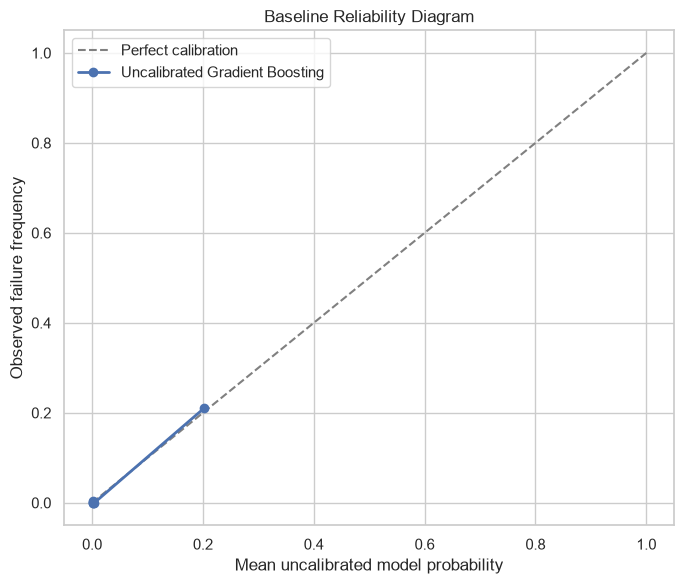

In [5]:
observed_rate, mean_score = calibration_curve(
    y_test, uncalibrated_scores, n_bins=6, strategy="quantile"
)
plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
plt.plot(mean_score, observed_rate, marker="o", linewidth=2,
         label="Uncalibrated Gradient Boosting")
plt.xlabel("Mean uncalibrated model probability")
plt.ylabel("Observed failure frequency")
plt.title("Baseline Reliability Diagram")
plt.legend(); plt.tight_layout(); plt.show()

## 4. CV-based calibration methods

Sigmoid calibration learns a smooth parametric mapping. Isotonic calibration learns a more flexible monotonic mapping but can overfit when calibration positives are limited. Both methods use five-fold stratified calibration entirely inside the training partition. The holdout labels are never supplied to either calibrator.

In [6]:
calibration_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sigmoid_model = CalibratedClassifierCV(
    estimator=make_gradient_boosting_pipeline(), method="sigmoid", cv=calibration_cv
)
isotonic_model = CalibratedClassifierCV(
    estimator=make_gradient_boosting_pipeline(), method="isotonic", cv=calibration_cv
)

sigmoid_model.fit(X_train, y_train)
isotonic_model.fit(X_train, y_train)
sigmoid_probabilities = sigmoid_model.predict_proba(X_test)[:, 1]
isotonic_probabilities = isotonic_model.predict_proba(X_test)[:, 1]

## 5. Calibration performance comparison

Brier Score and Log Loss are the primary calibration metrics. ROC-AUC and Average Precision check whether useful discrimination was preserved. Differences on this reused development holdout should be interpreted as comparative evidence, not precise population estimates.

In [7]:
score_sets = {
    "Uncalibrated Gradient Boosting": uncalibrated_scores,
    "Sigmoid calibrated": sigmoid_probabilities,
    "Isotonic calibrated": isotonic_probabilities,
}
comparison = pd.DataFrame({
    name: probability_metrics(y_test, scores) for name, scores in score_sets.items()
}).T
comparison.style.format("{:.4f}").highlight_min(
    subset=["Brier Score", "Log Loss"], color="#c7f0d8"
).highlight_max(
    subset=["ROC-AUC", "Average Precision"], color="#dbeafe"
)

,Brier Score,Log Loss,ROC-AUC,Average Precision,Precision @ 0.50,Recall @ 0.50,F1 @ 0.50
Uncalibrated Gradient Boosting,0.0063,0.0318,0.9706,0.9014,1.0000,0.7941,0.8852
Sigmoid calibrated,0.0061,0.0311,0.9648,0.9063,1.0000,0.8088,0.8943
Isotonic calibrated,0.0063,0.0305,0.9719,0.9051,1.0000,0.7941,0.8852


## 6. Reliability-curve comparison

Curves closer to the diagonal are better calibrated. Because quantile bins contain similar observation counts rather than similar positive counts, visual differences—especially in the high-score tail—remain uncertain with only 68 holdout failures.

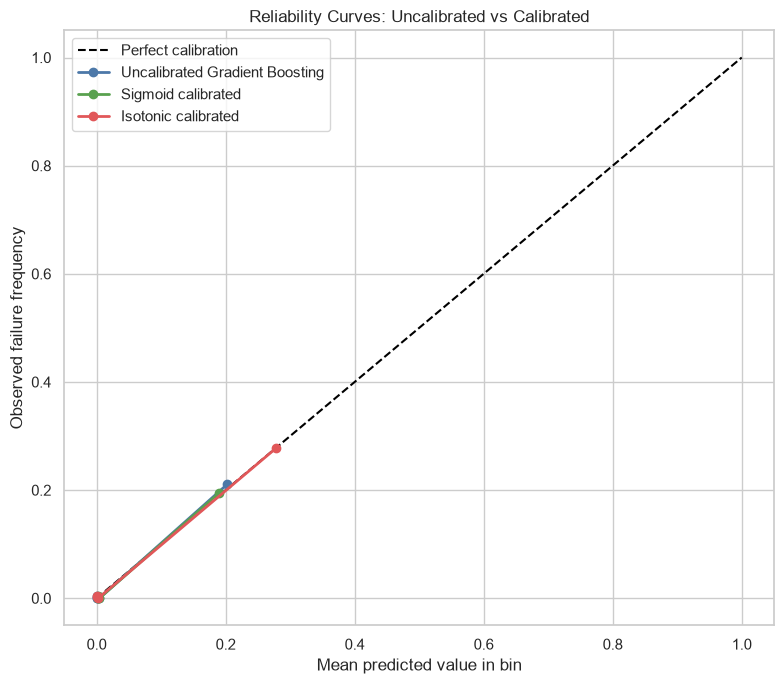

In [8]:
plt.figure(figsize=(8, 7))
plt.plot([0, 1], [0, 1], "--", color="black", label="Perfect calibration")
colors = ["#4c78a8", "#59a14f", "#e15759"]
for (name, scores), color in zip(score_sets.items(), colors):
    observed, predicted = calibration_curve(y_test, scores, n_bins=6, strategy="quantile")
    plt.plot(predicted, observed, marker="o", linewidth=2, color=color, label=name)
plt.xlabel("Mean predicted value in bin")
plt.ylabel("Observed failure frequency")
plt.title("Reliability Curves: Uncalibrated vs Calibrated")
plt.legend(); plt.tight_layout(); plt.show()

## 7. Selected approach and probability distributions

Sigmoid calibration is preferred for this development stage: it has the best Brier Score, slightly improves Log Loss, preserves strong discrimination, and is smoother than isotonic calibration. Isotonic achieves the lowest Log Loss by a small margin, but its Brier Score is slightly worse than the uncalibrated baseline and its flexibility is less attractive with relatively few training failures. Selection is therefore based on the full evidence, not a single tiny metric difference.

,count,mean,std,min,25%,50%,75%,90%,95%,max
Actual outcome,,,,,,,,,,
Failure,68.0,0.776373,0.335196,0.001600,0.839117,0.935238,0.972452,0.979619,0.984230,0.999885
Non-failure,1932.0,0.007407,0.025500,0.001183,0.001605,0.001677,0.003252,0.006845,0.029059,0.449990


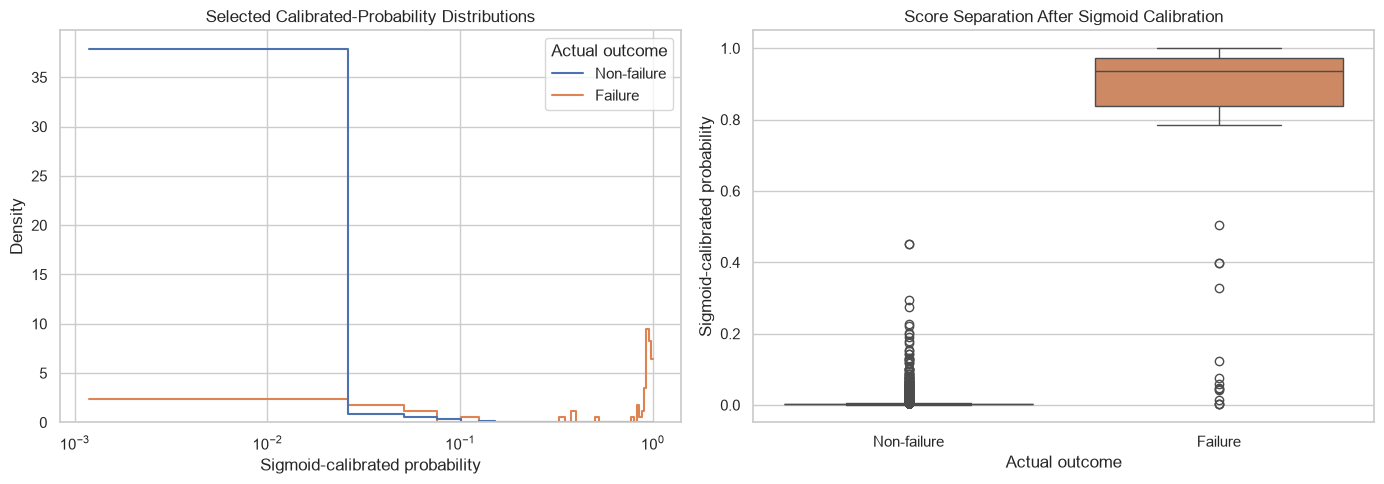

In [9]:
selected_probabilities = sigmoid_probabilities
distribution_data = pd.DataFrame({
    "Actual outcome": y_test.map({0: "Non-failure", 1: "Failure"}).to_numpy(),
    "Sigmoid-calibrated probability": selected_probabilities,
})
display(distribution_data.groupby("Actual outcome")["Sigmoid-calibrated probability"]
        .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=distribution_data, x="Sigmoid-calibrated probability",
             hue="Actual outcome", bins=40, stat="density",
             common_norm=False, element="step", fill=False, ax=axes[0])
axes[0].set_xscale("log"); axes[0].set_title("Selected Calibrated-Probability Distributions")
sns.boxplot(data=distribution_data, x="Actual outcome",
            y="Sigmoid-calibrated probability", hue="Actual outcome",
            legend=False, ax=axes[1])
axes[1].set_title("Score Separation After Sigmoid Calibration")
plt.tight_layout(); plt.show()

## 8. Interpretation, thresholds, and evaluation caveat

Sigmoid calibration improves the aggregate calibration metrics only modestly. With 68 holdout failures, synthetic data, no uncertainty intervals, and a repeatedly examined development holdout, the evidence is not yet strong enough for dashboard text such as **Estimated failure probability: 72%**. The safer language remains **Failure Risk Score: 72/100** until calibration is validated on independent data.

Notebook 03's Low/Medium/High/Critical boundaries were derived from **uncalibrated** out-of-fold Gradient Boosting scores. Calibration changes the numerical scale, so those values must not be silently applied to calibrated probabilities. If the calibrated model is adopted, category thresholds must be re-derived from calibrated out-of-fold training probabilities in a separate experiment. Notebook 03 is not changed here.

The same fixed holdout partition was already examined in earlier notebooks. It is suitable for development-stage comparison but is no longer a completely untouched project-level lockbox. A final independent lockbox or nested evaluation strategy is needed before definitive production or generalization claims.

## Calibration Conclusions

In [10]:
display(Markdown(f"""
The original Gradient Boosting scores show strong discrimination but are not validated real-world probabilities. Sigmoid calibration improves Brier Score from **{comparison.loc['Uncalibrated Gradient Boosting', 'Brier Score']:.4f}** to **{comparison.loc['Sigmoid calibrated', 'Brier Score']:.4f}** and Log Loss from **{comparison.loc['Uncalibrated Gradient Boosting', 'Log Loss']:.4f}** to **{comparison.loc['Sigmoid calibrated', 'Log Loss']:.4f}**, while retaining strong ROC-AUC and Average Precision.

Isotonic calibration produces the lowest Log Loss (**{comparison.loc['Isotonic calibrated', 'Log Loss']:.4f}**) but a slightly worse Brier Score than sigmoid and the baseline. Given the limited positive class, its flexible stepwise mapping carries greater overfitting risk. **Sigmoid calibration is the preferred development-stage approach**, based on calibration quality, smoothness, stability, and preserved ranking—not on one metric alone.

Literal failure-probability language is **not yet justified**. Continue displaying a model-derived Failure Risk Score until calibration is confirmed on a new independent lockbox with uncertainty analysis. The notebook 03 boundaries remain valid only for its uncalibrated scale; calibrated risk thresholds must later be re-derived from calibrated out-of-fold training probabilities.

Limitations include synthetic and imbalanced data, only 68 holdout failures, no repeated-CV or bootstrap uncertainty analysis, and reuse of the development holdout. **Next:** validate sigmoid calibration and its stability on a new project-level lockbox before changing dashboard language or category thresholds.
"""))


The original Gradient Boosting scores show strong discrimination but are not validated real-world probabilities. Sigmoid calibration improves Brier Score from **0.0063** to **0.0061** and Log Loss from **0.0318** to **0.0311**, while retaining strong ROC-AUC and Average Precision.

Isotonic calibration produces the lowest Log Loss (**0.0305**) but a slightly worse Brier Score than sigmoid and the baseline. Given the limited positive class, its flexible stepwise mapping carries greater overfitting risk. **Sigmoid calibration is the preferred development-stage approach**, based on calibration quality, smoothness, stability, and preserved ranking—not on one metric alone.

Literal failure-probability language is **not yet justified**. Continue displaying a model-derived Failure Risk Score until calibration is confirmed on a new independent lockbox with uncertainty analysis. The notebook 03 boundaries remain valid only for its uncalibrated scale; calibrated risk thresholds must later be re-derived from calibrated out-of-fold training probabilities.

Limitations include synthetic and imbalanced data, only 68 holdout failures, no repeated-CV or bootstrap uncertainty analysis, and reuse of the development holdout. **Next:** validate sigmoid calibration and its stability on a new project-level lockbox before changing dashboard language or category thresholds.
